In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from collections import Counter

from dotenv import load_dotenv
import os
load_dotenv()
YOUR_HF_TOKEN = os.getenv("YOUR_HF_TOKEN")

/home/bistreamt/Desktop/master/research 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def combine_text(row):
    # Collect all existing description parts in order
    desc_parts = [row.get(f"case_description_{i}", "") for i in range(1, 9) if row.get(f"case_description_{i}")]
    # Collect all existing justification parts in order
    just_parts = [row.get(f"justification_{i}", "") for i in range(1, 5) if row.get(f"justification_{i}")]
    
    # Prioritize description by putting it first
    return " ".join(desc_parts + just_parts)

In [3]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
            
        loss_fct = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    # predictions = (logits > 0).astype(int)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "precision_macro": precision_score(labels, predictions, average="macro"),
        "recall_macro": recall_score(labels, predictions, average="macro")
    }

In [4]:
def plot_history(log_history):
    train_loss = []
    val_loss = []
    val_acc = []
    val_f1 = []
    
    for log in log_history:
        if "loss" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
    
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
    
        if "eval_accuracy" in log:
            val_acc.append(log["eval_accuracy"])
    
        if "eval_f1_macro" in log:
            val_f1.append(log["eval_f1_macro"])
    
    
    # Convert to numpy arrays if needed
    train_loss = np.array(train_loss)
    val_loss = np.array(val_loss)
    val_acc = np.array(val_acc)
    val_f1 = np.array(val_f1)
    
    # X axes
    train_steps = np.arange(len(train_loss))
    val_steps = np.linspace(0, len(train_loss)-1, len(val_loss))
    
    # Create figure
    plt.figure(figsize=(12, 5))
    # plt.title("Supreme Court Decisions - JurBERT - 3 labels")
    
    # ----- Left subplot: Train / Val Loss -----
    plt.subplot(1, 2, 1)
    plt.plot(train_steps, train_loss, marker='o', label="Train Loss", linewidth=2)
    plt.plot(val_steps, val_loss, marker='o', label="Val Loss", linewidth=2)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # ----- Right subplot: Val Acc / Val F1 -----
    plt.subplot(1, 2, 2)
    plt.plot(val_steps, val_acc, marker='o', label="Val Accuracy", linewidth=2)
    plt.plot(val_steps, val_f1, marker='o', label="Val F1 Macro", linewidth=2)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title("Validation Accuracy & F1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SUPREME COURT DECISIONS

In [6]:
with open("data/supreme-court-data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

if isinstance(data, list):
    labels = [item["label"] for item in data if "label" in item]
    
    label_counts = Counter(labels)
    
    print("Number of samples per label:")
    for label, count in sorted(label_counts.items()):
        print(f"{label:12} : {count:4d} samples")
    
    print(f"\nTotal samples in Supreme Court Data: {len(data)}")

Number of samples per label:
admis        :  396 samples
inadmisibil  :  588 samples
respins      :  416 samples

Total samples in Supreme Court Data: 1400


In [7]:
# Define your mapping
path = "data/supreme-court-data.json"
label_map = {
    "respins": 0,
    "admis": 1,
    "inadmisibil": 2,
}

def prepare_dataset(json_file_path, num_labels):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    if num_labels == 2:
        data = [item for item in data if item['label'] != 'inadmisibil']

    formatted_data = []
    for entry in data:
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        just = " ".join([entry.get(f"justification_{i}", "") for i in range(1, 5)]).strip()
        
        formatted_data.append({
            "text": f"{desc} {just}", # Description prioritized by order
            "label": label_map[entry["label"]]
        })
    
    # Split into train and validation (85/15)
    train_data, val_data = train_test_split(
        formatted_data, 
        test_size=0.15, 
        stratify=[d["label"] for d in formatted_data], # Keep class ratios same
        random_state=42
    )
    
    return Dataset.from_list(train_data), Dataset.from_list(val_data)

## JurBERT - 3 labels

In [8]:
train_raw, val_raw = prepare_dataset(path, 3)

model_name = "readerbench/jurBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 1190/1190 [00:02<00:00, 589.02 examples/s]


The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 210/210 [00:00<00:00, 699.08 examples/s]

Original train cases: 1190
Tokenized train windows: 11041


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/supreme-jurbert-3",
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    warmup_ratio=0.15,
    per_device_train_batch_size=16,
    # gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.4,
    fp16=True,
    logging_steps=150,
    eval_steps=150,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/jurBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
150,1.019400,0.793832,0.770697,0.583242,0.718642,0.620740
300,0.796400,0.612442,0.838780,0.728921,0.835261,0.744323
450,0.718500,0.575045,0.874183,0.829034,0.853892,0.821640
600,0.649700,0.521335,0.888344,0.848102,0.898574,0.821832
750,0.620700,0.511374,0.885621,0.848779,0.882720,0.824154
900,0.597900,0.514799,0.894336,0.859918,0.893870,0.844572
1050,0.547200,0.490518,0.898148,0.864241,0.897424,0.843392
1200,0.526500,0.492499,0.905229,0.873467,0.914229,0.858707
1350,0.510200,0.505973,0.893246,0.855914,0.871699,0.857453
1500,0.493900,0.490475,0.901416,0.871836,0.900993,0.855503


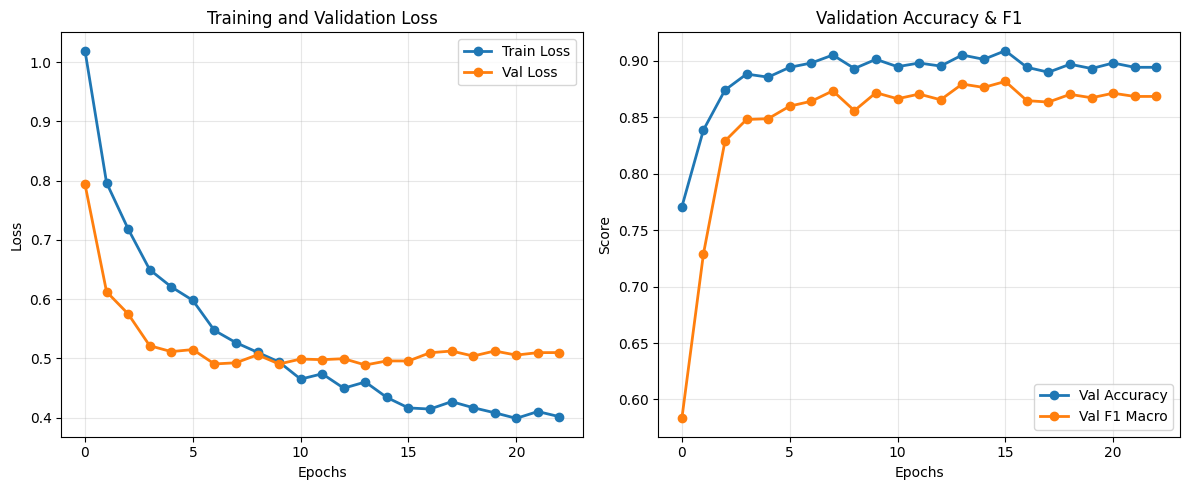

In [10]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)

## JurBERT - 2 labels

In [11]:
train_raw, val_raw = prepare_dataset(path, 2)

model_name = "readerbench/jurBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 690/690 [00:00<00:00, 799.17 examples/s]


The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 122/122 [00:00<00:00, 1032.10 examples/s]

Original train cases: 690
Tokenized train windows: 4671


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/supreme-jurbert-2",
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    warmup_ratio=0.15,
    per_device_train_batch_size=16,
    # gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.4,
    fp16=True,
    logging_steps=150,
    eval_steps=150,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/jurBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
150,0.684100,0.575712,0.802985,0.800417,0.798982,0.805634
300,0.532300,0.394615,0.888060,0.886929,0.885513,0.895201
450,0.447000,0.371542,0.888060,0.886929,0.885513,0.895201
600,0.380400,0.398249,0.868657,0.868393,0.876363,0.884419
750,0.354700,0.381109,0.880597,0.879928,0.881614,0.891738
900,0.317900,0.363530,0.900000,0.898864,0.896932,0.906472
1050,0.295100,0.371551,0.892537,0.891726,0.891631,0.902021
1200,0.283100,0.405880,0.876119,0.875740,0.881191,0.890352
1350,0.274300,0.384991,0.885075,0.884405,0.885827,0.896088


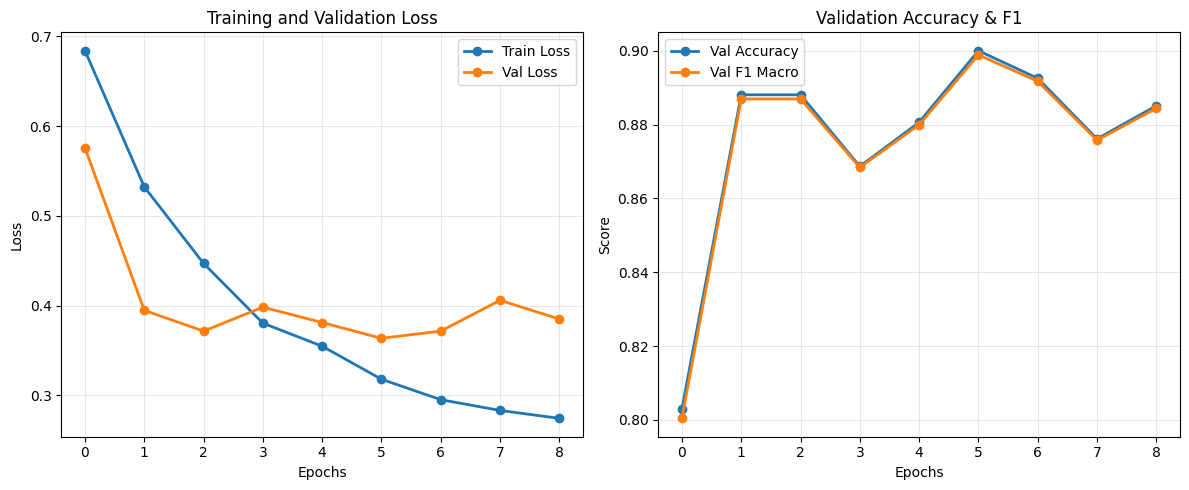

In [13]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)

## RoBERT - 3 labels

In [14]:
train_raw, val_raw = prepare_dataset(path, 3)

model_name = "readerbench/RoBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

Map: 100%|██████████| 210/210 [00:00<00:00, 624.65 examples/s]

Original train cases: 1190
Tokenized train windows: 11038


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/supreme-robert-3",
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    # gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.2,
    fp16=True,
    logging_steps=150,
    eval_steps=150,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/RoBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
150,0.856000,0.604064,0.832700,0.749419,0.822251,0.708585
300,0.735400,0.606071,0.847909,0.754054,0.844510,0.764931
450,0.602800,0.608320,0.858772,0.807398,0.829584,0.803299
600,0.543300,0.668775,0.831070,0.774886,0.781818,0.798082
750,0.498800,0.626074,0.848995,0.800843,0.806611,0.803236
900,0.460200,0.589943,0.873982,0.838660,0.850099,0.828707
1050,0.472900,0.625624,0.875068,0.830960,0.885058,0.807896
1200,0.461700,0.591217,0.878870,0.832951,0.871689,0.830343
1350,0.451500,0.641620,0.853341,0.806474,0.822031,0.811208
1500,0.403300,0.606504,0.864204,0.826301,0.837218,0.827163


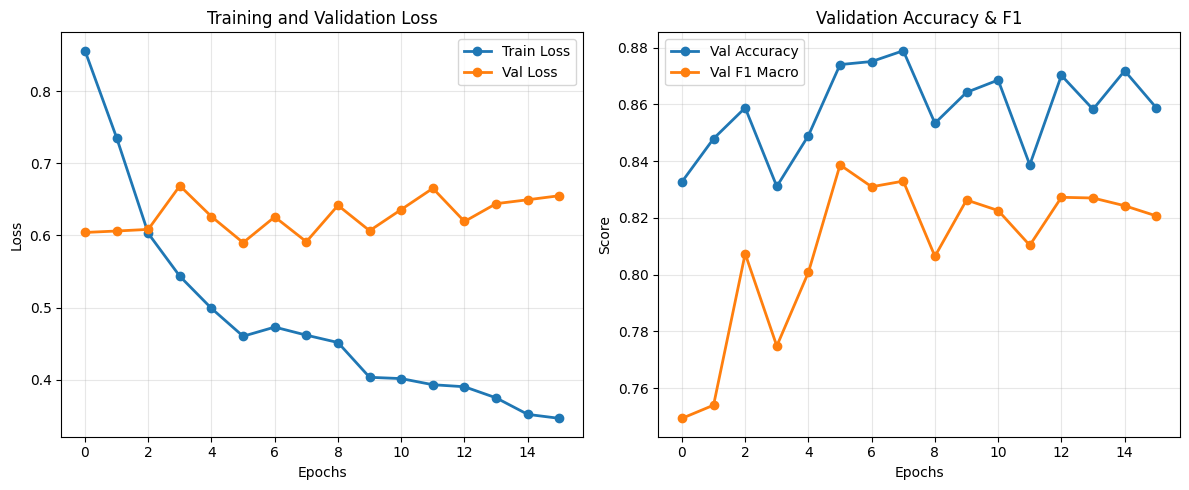

In [16]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)

## RoBERT - 2 labels

In [17]:
train_raw, val_raw = prepare_dataset(path, 2)

model_name = "readerbench/RoBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

Map: 100%|██████████| 122/122 [00:00<00:00, 984.35 examples/s] 

Original train cases: 690
Tokenized train windows: 4648


In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/supreme-robert-2",
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    # gradient_accumulation_steps=2,
    num_train_epochs=5,
    weight_decay=0.2,
    fp16=True,
    logging_steps=150,
    eval_steps=150,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/RoBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
150,0.610000,0.399151,0.870728,0.867566,0.866752,0.868481
300,0.440800,0.394220,0.879643,0.877645,0.875352,0.882085
450,0.365800,0.410083,0.878158,0.875888,0.873771,0.879324
600,0.319800,0.450129,0.854383,0.853012,0.852199,0.861335
750,0.262800,0.464871,0.872214,0.871355,0.872094,0.882117


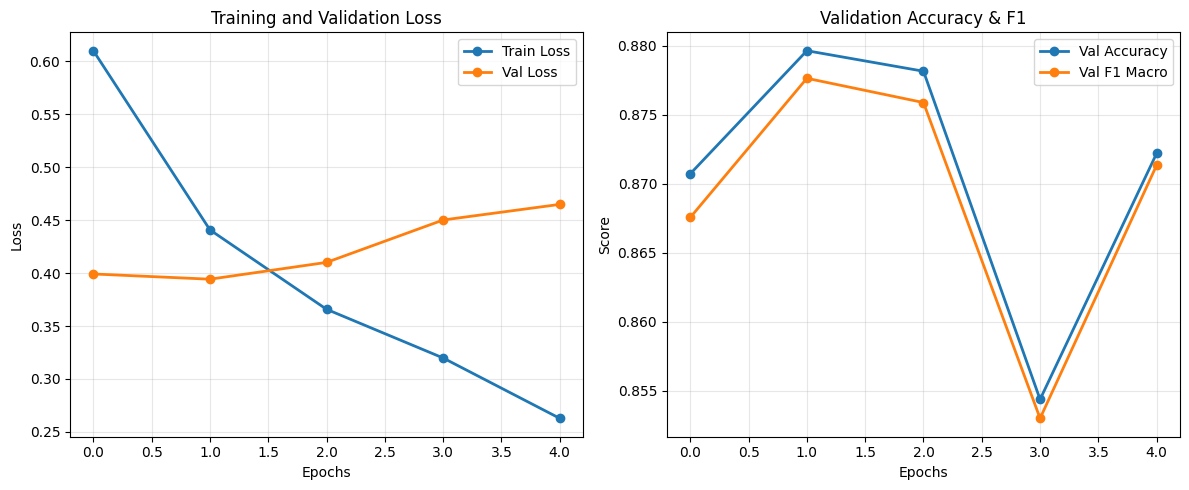

In [19]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)

# REGIONAL COURT DECISIONS

In [20]:
with open("data/regional-court-data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)

if isinstance(data, list):
    labels = [item["label"] for item in data if "label" in item]
    
    label_counts = Counter(labels)
    
    print("Number of samples per label:")
    for label, count in sorted(label_counts.items()):
        print(f"{label:12} : {count:4d} samples")
    
    print(f"\nTotal samples in Regional Court Data: {len(data)}")

Number of samples per label:
nevinovat    : 3626 samples
vinovat      : 5244 samples

Total samples in Regional Court Data: 8870


In [21]:
# Define your mapping
path = "data/regional-court-data.json"
label_map = {
    "vinovat": 0,
    "nevinovat": 1
}

def prepare_dataset(json_file_path):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    formatted_data = []
    for entry in data:
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        # just = " ".join([entry.get(f"justification_{i}", "") for i in range(1, 5)]).strip()
        
        formatted_data.append({
            "text": f"{desc}", # Description prioritized by order
            "label": label_map[entry["label"]]
        })
    
    # Split into train and validation (85/15)
    train_data, val_data = train_test_split(
        formatted_data, 
        test_size=0.15, 
        stratify=[d["label"] for d in formatted_data], # Keep class ratios same
        random_state=42
    )
    
    return Dataset.from_list(train_data), Dataset.from_list(val_data)

train_raw, val_raw = prepare_dataset(path)

## JurBERT

In [22]:
model_name = "readerbench/jurBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 7539/7539 [00:23<00:00, 326.50 examples/s]


The OrderedVocab you are attempting to save contains holes for indices [6, 7, 10, 41], your vocabulary could be corrupted!


Map: 100%|██████████| 1331/1331 [00:04<00:00, 313.32 examples/s]

Original train cases: 7539
Tokenized train windows: 119329


In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/regional-jurbert",
    learning_rate=2e-6,
    lr_scheduler_type="reduce_lr_on_plateau",
    warmup_steps=500,
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.1,
    fp16=True,
    logging_steps=500,
    eval_steps=500,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/jurBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
500,0.653000,0.621539,0.662887,0.653068,0.659469,0.652460
1000,0.595800,0.583038,0.711621,0.709926,0.709577,0.711337
1500,0.566600,0.576340,0.720091,0.710986,0.721032,0.709315
2000,0.549600,0.559620,0.735456,0.733340,0.732888,0.734107
2500,0.540200,0.553918,0.738973,0.734375,0.736733,0.733212
3000,0.530000,0.555080,0.741334,0.733761,0.742466,0.731715
3500,0.518900,0.547775,0.749711,0.743135,0.750214,0.741089
4000,0.514900,0.543379,0.751007,0.748100,0.748316,0.747906
4500,0.505400,0.540852,0.756607,0.752462,0.754700,0.751264
5000,0.499300,0.541157,0.760865,0.758313,0.758267,0.758361


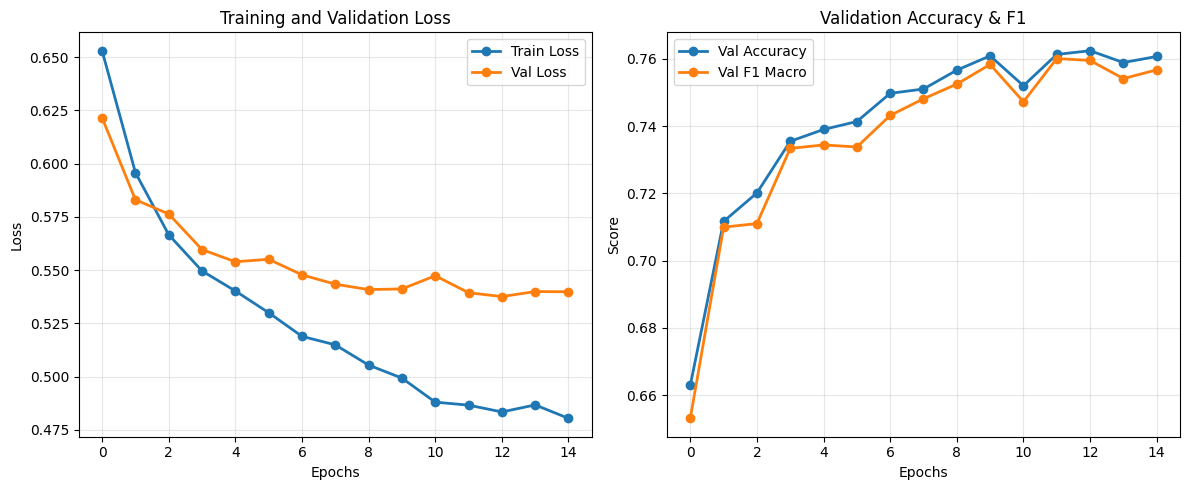

In [24]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)

## RoBERT

In [25]:
model_name = "readerbench/RoBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        stride=256,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    
    # Since one case can become 3-4 chunks, we must duplicate the label for each chunk
    sample_mapping = tokenized_inputs.pop("overflow_to_sample_mapping")
    labels = examples["label"]
    tokenized_inputs["labels"] = [labels[i] for i in sample_mapping]
    
    return tokenized_inputs

tokenized_train = train_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=train_raw.column_names
)

tokenized_val = val_raw.map(
    tokenize_and_align_labels, 
    batched=True, 
    remove_columns=val_raw.column_names
)

print(f"Original train cases: {len(train_raw)}")
print(f"Tokenized train windows: {len(tokenized_train)}")

Map: 100%|██████████| 1331/1331 [00:04<00:00, 326.47 examples/s]

Original train cases: 7539
Tokenized train windows: 113931


In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
    ).to(device) 
print(f"Using device: {device}")

training_args = TrainingArguments(
    output_dir="results/regional-robert",
    learning_rate=1e-5,
    lr_scheduler_type="reduce_lr_on_plateau",
    warmup_steps=300,
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.1,
    fp16=True,
    logging_steps=500,
    eval_steps=500,
    eval_strategy="steps",
    save_strategy="epoch",
    metric_for_best_model="f1_macro", 
    greater_is_better=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train, # Your processed dataset
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at readerbench/RoBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
500,0.612500,0.599968,0.701731,0.700649,0.700784,0.702700
1000,0.556600,0.569459,0.740172,0.738517,0.738053,0.739573
1500,0.527100,0.568241,0.743613,0.738127,0.742941,0.736502
2000,0.493700,0.601460,0.731640,0.727545,0.729265,0.726634
2500,0.465500,0.596579,0.741626,0.739861,0.739401,0.740760
3000,0.444900,0.582884,0.751563,0.750006,0.749511,0.751142
3500,0.429200,0.625885,0.727665,0.722594,0.725765,0.721354
4000,0.395000,0.620075,0.747637,0.746840,0.747043,0.749469
4500,0.383500,0.645034,0.739784,0.737517,0.737260,0.737838


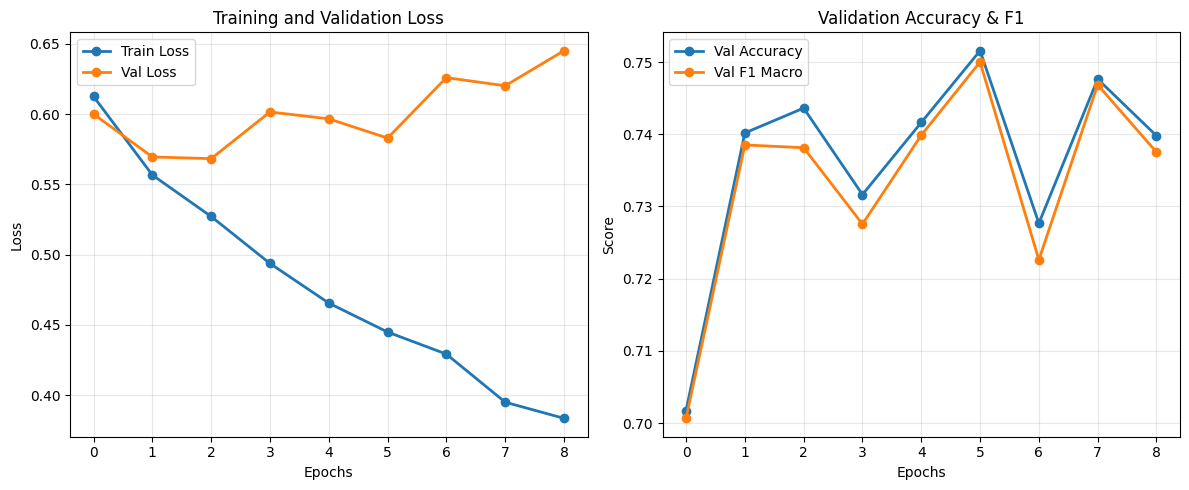

In [27]:
trainer.train()

log_history = trainer.state.log_history
plot_history(log_history)